# 🎓 Student Performance Analysis using Python

### 📘 Objective
To analyze student performance based on gender, parental education, and test preparation using **NumPy**, **Pandas**, **Matplotlib**, and **Seaborn**.

### 🧠 Goal
We aim to identify key factors that influence students' academic success and visualize performance patterns.

### 🧰 Libraries Used
- **NumPy** → for mathematical and numerical operations  
- **Pandas** → for data handling and analysis  
- **Matplotlib** → for visualizations  
- **Seaborn** → for advanced plots and styling


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

## 📂 Step 1: Load the Dataset

We are using the **StudentsPerformance.csv** dataset from Kaggle.  
Upload the file into Google Colab before running the code below.


In [ ]:
df=pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 🔍 Step 2: Explore the Dataset

Let’s check the structure, datatypes, and missing values to understand the dataset better.


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()
df.isnull().sum()

Rows: 1000
Columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race/ethnicity               1000 non-null   object 
 2   parental level of education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test preparation course      1000 non-null   object 
 5   math score                   1000 non-null   int64  
 6   reading score                1000 non-null   int64  
 7   writing score                1000 non-null   int64  
 8   Avg_score                    1000 non-null   float64
 9   Grade                        1000 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 78.3+ KB


,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0
Avg_score,0
Grade,0


In [ ]:
df.describe()

,math score,reading score,writing score,Avg_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770580
std,15.16308,14.600192,15.195657,14.257311
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.330000
50%,66.00000,70.000000,69.000000,68.330000
75%,77.00000,79.000000,79.000000,77.670000
max,100.00000,100.000000,100.000000,100.000000


## 🧮 Step 3: Feature Engineering

We'll calculate an **average score** from math, reading, and writing scores, and then assign letter grades (A, B, C, D) based on performance.


In [ ]:
df['Avg_score']=np.round(df[['math score','reading score','writing score']].mean(axis=1),2)
df['Grade']=np.where(df['Avg_score']>=90,'A',
            np.where(df['Avg_score']>=75,'B',
            np.where(df['Avg_score']>=60,'C','D')))
df[['gender','Avg_score','Grade']].head()

,gender,Avg_score,Grade
0,female,72.67,C
1,female,82.33,B
2,female,92.67,A
3,male,49.33,D
4,male,76.33,B


In [ ]:
df.groupby('gender')[['math score','reading score','writing score']].mean()
df.groupby('test preparation course')[['math score','reading score','writing score']].mean()
df['Grade'].value_counts()

,count
Grade,
C,391
D,285
B,272
A,52


# 📊 Step 4: Data Visualization

Now we’ll visualize the data to understand trends and relationships.

We’ll use:
- Histograms → to view distributions  
- Boxplots → to compare groups  
- Countplots → to show frequency of grades  
- Heatmaps → to show correlations  
- Pairplots → to visualize
- Bargraph → to show Average
multi-variable relationships


### 🎯 Average Score Distribution by Gender
We can use `hue='gender'` to compare how scores differ between male and female students.


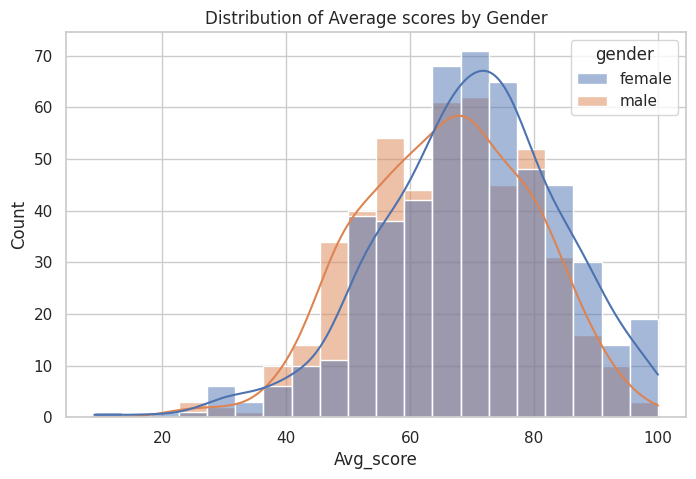

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='Avg_score',hue='gender',bins=20,kde=True,color='skyblue')
plt.title('Distribution of Average scores by Gender')
plt.show()



### 📊 **Average Score by Gender and Grade**

This bar plot shows how students’ average scores vary across different grades and genders, helping visualize performance differences.


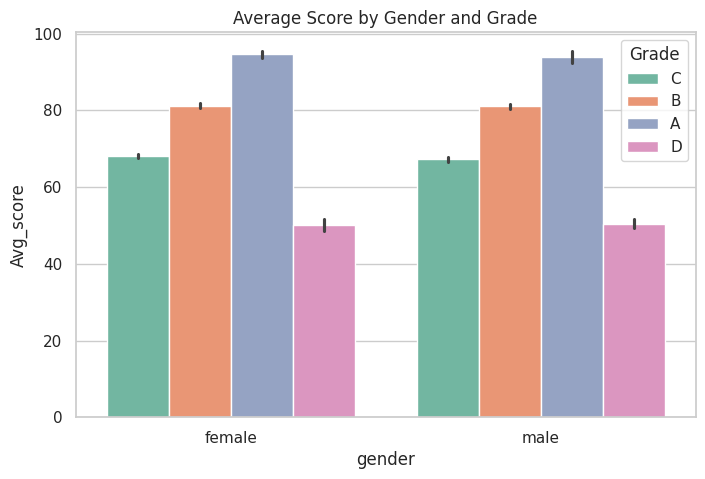

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='gender', y='Avg_score',hue='Grade', data=df, palette='Set2')
plt.title('Average Score by Gender and Grade')
plt.show()

### 📘 Test Preparation Effect
Let’s check if completing the **test preparation course** improves student performance.


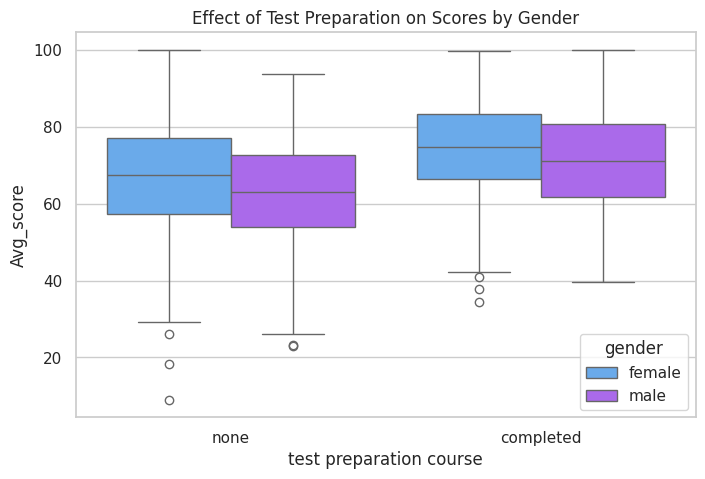

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='test preparation course', y='Avg_score',hue='gender', data=df, palette='cool')
plt.title('Effect of Test Preparation on Scores by Gender')
plt.show()

## 🔗 Step 5: Correlation Between Subjects

Now we’ll visualize the relationships between math, reading, writing, and average scores using a heatmap.


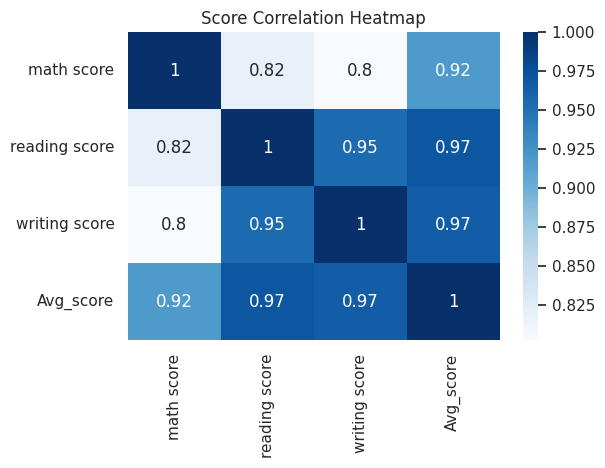

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score','reading score','writing score','Avg_score']].corr(), annot=True, cmap='Blues')
plt.title('Score Correlation Heatmap')
plt.show()

### 🏅 Grade Distribution by Gender
This plot shows how grades are distributed among male and female students.


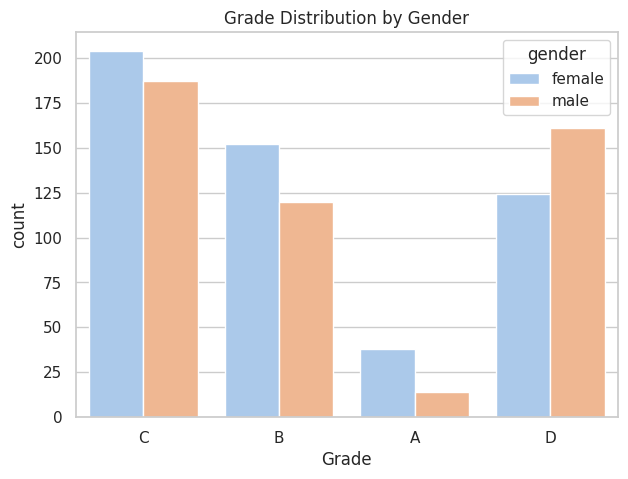

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='Grade', hue='gender', data=df, palette='pastel')
plt.title('Grade Distribution by Gender')
plt.show()


### 🔍 Pairplot Analysis
This shows pairwise relationships between all subject scores and highlights gender differences.


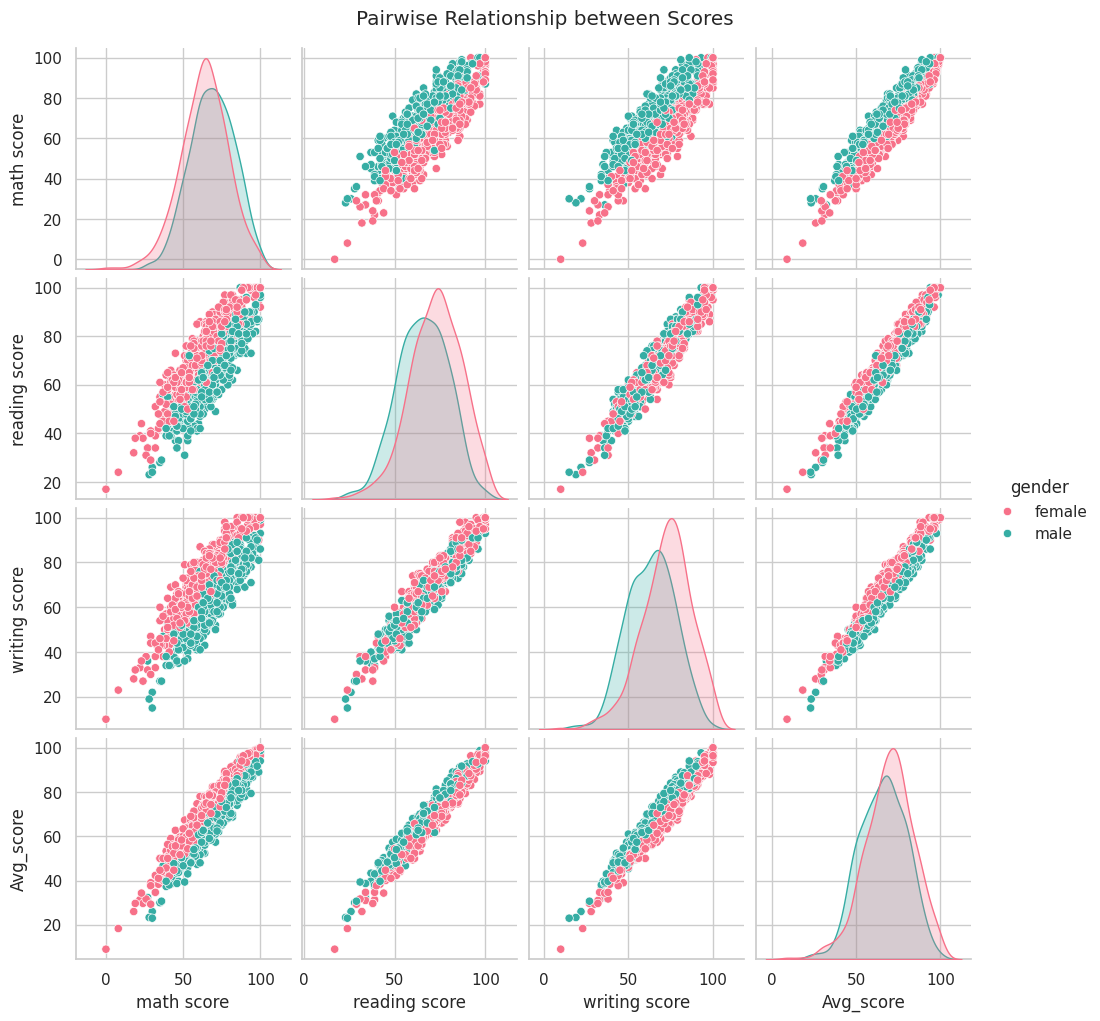

In [ ]:
sns.pairplot(df, vars=['math score','reading score','writing score','Avg_score'], hue='gender', palette='husl')
plt.suptitle("Pairwise Relationship between Scores", y=1.02)
plt.show()

### 🎓 Parental Education and Performance
We’ll now explore how a parent’s education level influences student scores.


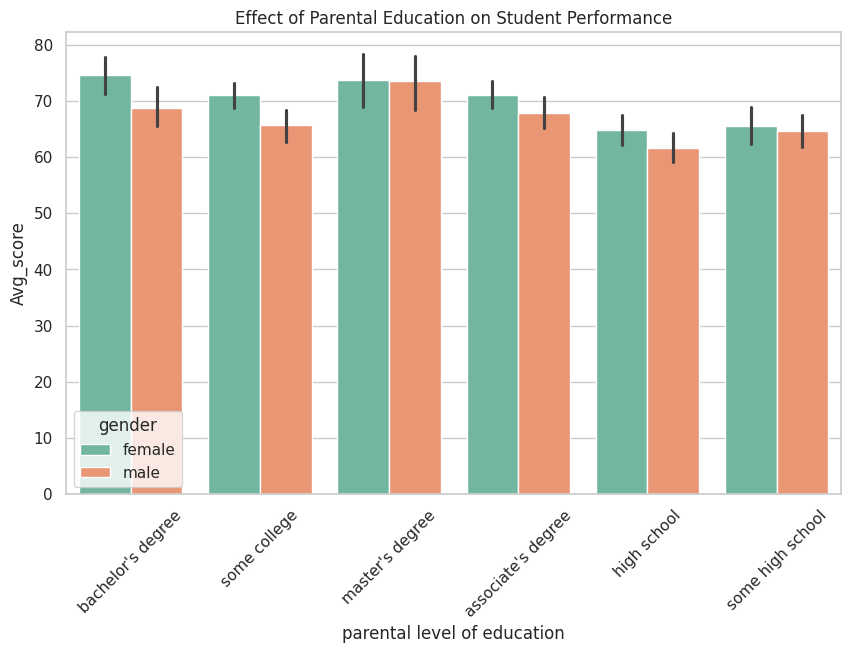

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='parental level of education', y='Avg_score', hue='gender', data=df, palette='Set2')
plt.title('Effect of Parental Education on Student Performance')
plt.xticks(rotation=45)
plt.show()

## 📈 Step 6: Statistical Insights
Let’s calculate the highest, lowest, mean, and median average scores.


In [ ]:
print("Highest Average Score:", np.max(df['Avg_score']))
print("Lowest Average Score:", np.min(df['Avg_score']))
print("Mean Average Score:", np.mean(df['Avg_score']))
print("Median Average Score:", np.median(df['Avg_score']))

Highest Average Score: 100.0
Lowest Average Score: 9.0
Mean Average Score: 67.77057999999998
Median Average Score: 68.33


### 🏆 Top 5 Students
Let's view the top 5 students with the highest average scores.


In [ ]:
top_students = df.sort_values(by='Avg_score', ascending=False).head(5)
top_students[['gender','math score','reading score','writing score','Avg_score','Grade']]

,gender,math score,reading score,writing score,Avg_score,Grade
916,male,100,100,100,100.00,A
962,female,100,100,100,100.00,A
458,female,100,100,100,100.00,A
114,female,99,100,100,99.67,A
712,female,98,100,99,99.00,A


### 🧮 Subject-wise Correlation Table
This table displays how strongly each subject correlates with others.


In [ ]:
corr_matrix = df[['math score','reading score','writing score','Avg_score']].corr()
corr_matrix

,math score,reading score,writing score,Avg_score
math score,1.000000,0.817580,0.802642,0.918744
reading score,0.817580,1.000000,0.954598,0.970331
writing score,0.802642,0.954598,1.000000,0.965669
Avg_score,0.918744,0.970331,0.965669,1.000000


## 💡 Step 7: Key Insights

- Female students perform better in reading and writing.  
- Males perform slightly better in math.  
- Students who complete test preparation courses achieve higher average scores.  
- Parental education positively influences performance.  
- Reading and writing scores are highly correlated.


### 💾 Saving the Cleaned Dataset
This step exports the processed DataFrame into a CSV file.
It ensures that all analysis results, grades, and average scores are stored safely for future use.


In [ ]:
df.to_csv("student_performance_summary.csv", index=False)
print("✅ Summary saved successfully!")


✅ Summary saved successfully!


# ✅ Conclusion

This project analyzed student performance data using **NumPy, Pandas, Matplotlib, and Seaborn**.  
We explored factors like gender, test preparation, and parental education and visualized their impact on scores.

### 📊 Learnings:
- Learned to clean and analyze data using Pandas.  
- Practiced NumPy for mathematical computations.  
- Created multiple visualizations using Seaborn and Matplotlib.  
- Derived actionable insights from real-world data.

**Outcome:**  
A deeper understanding of how to use Python libraries for data analytics.

**Tools Used:** NumPy, Pandas, Matplotlib, Seaborn  
**Dataset:** StudentsPerformance.csv (from Kaggle)
